# Duplicate Detection & Removal
**IT Number:** IT25103007 · **Name:** Sooriyaarachchi S.A.V.S. · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
Duplicate rows inflate certain weather conditions in the dataset and can bias both the EDA statistics and any model trained downstream (a repeated hour is effectively double-counted evidence for whatever `suitability` label it produces). This notebook detects exact duplicate rows and removes them, and also standardizes the `Formatted Date` column to a real datetime type, since duplicate-checking and any later time-based work both depend on a clean, comparable timestamp.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/weatherHistory.csv")
print("Shape before:", df.shape)

Shape before: (96453, 12)


In [9]:
dupe_mask = df.duplicated()
print("Duplicate rows found:", dupe_mask.sum())
df[dupe_mask].head(10)

Duplicate rows found: 24


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
36072,2010-08-02 00:00:00.000 +0200,Clear,rain,18.800000,18.800000,0.93,6.2790,270.0,14.9086,0.0,1016.99,Partly cloudy starting in the afternoon contin...
36073,2010-08-02 01:00:00.000 +0200,Clear,rain,18.222222,18.222222,0.97,6.2790,291.0,14.9086,0.0,1017.09,Partly cloudy starting in the afternoon contin...
36074,2010-08-02 02:00:00.000 +0200,Clear,rain,18.072222,18.072222,0.98,11.2700,290.0,6.8425,0.0,1013.23,Partly cloudy starting in the afternoon contin...
36075,2010-08-02 03:00:00.000 +0200,Clear,rain,16.622222,16.622222,0.99,6.4400,300.0,11.9784,0.0,1016.78,Partly cloudy starting in the afternoon contin...
36076,2010-08-02 04:00:00.000 +0200,Clear,rain,16.094444,16.094444,0.99,3.0751,280.0,11.9784,0.0,1016.67,Partly cloudy starting in the afternoon contin...
36077,2010-08-02 05:00:00.000 +0200,Clear,rain,15.955556,15.955556,0.99,3.8801,276.0,9.9820,0.0,1016.69,Partly cloudy starting in the afternoon contin...
36078,2010-08-02 06:00:00.000 +0200,Clear,rain,17.088889,17.088889,1.00,6.4400,310.0,9.9820,0.0,1017.08,Partly cloudy starting in the afternoon contin...
36079,2010-08-02 07:00:00.000 +0200,Clear,rain,20.822222,20.822222,0.87,3.2200,300.0,9.9820,0.0,1017.27,Partly cloudy starting in the afternoon contin...
36080,2010-08-02 08:00:00.000 +0200,Clear,rain,23.405556,23.405556,0.74,1.8837,334.0,9.9820,0.0,1017.27,Partly cloudy starting in the afternoon contin...
36081,2010-08-02 09:00:00.000 +0200,Clear,rain,26.050000,26.050000,0.59,1.5939,5.0,9.9820,0.0,1017.15,Partly cloudy starting in the afternoon contin...


In [10]:
dupes = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:", len(dupes))

Total rows involved in duplicate groups: 48


In [16]:
dupes.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
8040,2010-08-02 00:00:00.000 +0200,Clear,rain,18.800000,18.800000,0.93,6.2790,270.0,14.9086,0.0,1016.99,Partly cloudy starting in the afternoon contin...
8041,2010-08-02 01:00:00.000 +0200,Clear,rain,18.222222,18.222222,0.97,6.2790,291.0,14.9086,0.0,1017.09,Partly cloudy starting in the afternoon contin...
8042,2010-08-02 02:00:00.000 +0200,Clear,rain,18.072222,18.072222,0.98,11.2700,290.0,6.8425,0.0,1013.23,Partly cloudy starting in the afternoon contin...
8043,2010-08-02 03:00:00.000 +0200,Clear,rain,16.622222,16.622222,0.99,6.4400,300.0,11.9784,0.0,1016.78,Partly cloudy starting in the afternoon contin...
8044,2010-08-02 04:00:00.000 +0200,Clear,rain,16.094444,16.094444,0.99,3.0751,280.0,11.9784,0.0,1016.67,Partly cloudy starting in the afternoon contin...
8045,2010-08-02 05:00:00.000 +0200,Clear,rain,15.955556,15.955556,0.99,3.8801,276.0,9.9820,0.0,1016.69,Partly cloudy starting in the afternoon contin...
8046,2010-08-02 06:00:00.000 +0200,Clear,rain,17.088889,17.088889,1.00,6.4400,310.0,9.9820,0.0,1017.08,Partly cloudy starting in the afternoon contin...
8047,2010-08-02 07:00:00.000 +0200,Clear,rain,20.822222,20.822222,0.87,3.2200,300.0,9.9820,0.0,1017.27,Partly cloudy starting in the afternoon contin...
8048,2010-08-02 08:00:00.000 +0200,Clear,rain,23.405556,23.405556,0.74,1.8837,334.0,9.9820,0.0,1017.27,Partly cloudy starting in the afternoon contin...
8049,2010-08-02 09:00:00.000 +0200,Clear,rain,26.050000,26.050000,0.59,1.5939,5.0,9.9820,0.0,1017.15,Partly cloudy starting in the afternoon contin...


24 fully duplicate rows exist (every column identical, including the timestamp) — these are exact repeats, not just two different hours with similar weather, so it's safe to drop them outright rather than needing a more careful near-duplicate check.

In [11]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Shape after removing duplicates: (96429, 12)
Duplicates remaining: 0


With duplicates gone, the `Formatted Date` column is converted from text to a proper timezone-aware `datetime64` type. This is needed for every later time-based step in the group's pipeline (monthly/hourly trends, the `year`/`month`/`hour` features Member 5 builds), and it also lets us double check for duplicate *timestamps* that might not have been byte-for-byte identical rows.

In [12]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
print(df["Formatted Date"].dtype)

dupe_timestamps = df["Formatted Date"].duplicated().sum()
print("Duplicate timestamps (same hour logged twice with different readings):", dupe_timestamps)

datetime64[us, UTC]
Duplicate timestamps (same hour logged twice with different readings): 0


In [13]:
import os
os.makedirs("../results/outputs", exist_ok=True)
df.to_csv("../results/outputs/member2_duplicates_removed.csv", index=False)
print("Saved. Final shape:", df.shape)

Saved. Final shape: (96429, 12)


## 2. EDA Visualization

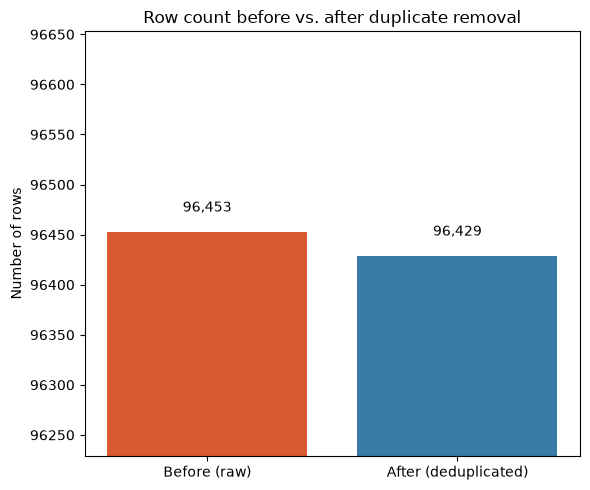

In [14]:
raw = pd.read_csv("../data/raw/weatherHistory.csv")
before_after = pd.Series({
    "Before (raw)": len(raw),
    "After (deduplicated)": len(df)
})

plt.figure(figsize=(6, 5))
bars = plt.bar(before_after.index, before_after.values, color=["#D85A30", "#3A7CA5"])
plt.title("Row count before vs. after duplicate removal")
plt.ylabel("Number of rows")
plt.ylim(before_after.min() - 200, before_after.max() + 200)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f"{int(b.get_height()):,}", ha="center")
plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member2_duplicate_check.png", dpi=110)
plt.show()

**Interpretation:** duplicates are a tiny fraction of the dataset (24 out of 96,453 rows, ~0.025%), so removing them barely moves the row count — but it's still worth doing, since an exact duplicate row contributes zero new information while silently doubling the weight of whatever weather condition it represents.